In [1]:
import pandas as pd

# 1. 读取 NicheCompass 原版文件
orig_enzymes_path = "/home/zhangjunyi/xiangmu/nichecompass-main/data/gene_programs/metabolite_enzyme_sensor_gps/human_metabolite_enzymes.tsv"
orig_sensors_path = "/home/zhangjunyi/xiangmu/nichecompass-main/data/gene_programs/metabolite_enzyme_sensor_gps/human_metabolite_sensors.tsv"

orig_enzymes = pd.read_csv(orig_enzymes_path, sep="\t")
orig_sensors = pd.read_csv(orig_sensors_path, sep="\t")

# 2. 读取你提取的肿瘤代谢文件
my_enzymes_path = "/home/zhangjunyi/xiangmu/nichecompass-main/data/pre_data/siyuanzu/MEBOCOST/tumor_metabolite_enzymes.tsv"
my_sensors_path = "/home/zhangjunyi/xiangmu/nichecompass-main/data/pre_data/siyuanzu/MEBOCOST/tumor_metabolite_sensors.tsv"

my_enzymes = pd.read_csv(my_enzymes_path, sep="\t")
my_sensors = pd.read_csv(my_sensors_path, sep="\t")

# 3. 打印列名对比
print("=== Enzymes 表头对比 ===")
print("原版 Enzymes 列名:", orig_enzymes.columns.tolist())
print("我的 Enzymes 列名:", my_enzymes.columns.tolist())
print("格式是否一致?", set(orig_enzymes.columns) == set(my_enzymes.columns))

print("\n=== Sensors 表头对比 ===")
print("原版 Sensors 列名:", orig_sensors.columns.tolist())
print("我的 Sensors 列名:", my_sensors.columns.tolist())
print("格式是否一致?", set(orig_sensors.columns) == set(my_sensors.columns))

=== Enzymes 表头对比 ===
原版 Enzymes 列名: ['metabolite', 'HMDB_ID', 'reaction', 'gene', 'direction']
我的 Enzymes 列名: ['metabolite', 'enzyme']
格式是否一致? False

=== Sensors 表头对比 ===
原版 Sensors 列名: ['ID', 'HMDB_ID', 'standard_metName', 'metName', 'Gene_name', 'Protein_name', 'Evidence', 'Annotation']
我的 Sensors 列名: ['metabolite', 'sensor']
格式是否一致? False


In [ ]:
import pandas as pd

# 文件路径
my_enzymes_path = "/home/zhangjunyi/xiangmu/nichecompass-main/data/pre_data/siyuanzu/MEBOCOST/tumor_metabolite_enzymes.tsv"
my_sensors_path = "/home/zhangjunyi/xiangmu/nichecompass-main/data/pre_data/siyuanzu/MEBOCOST/tumor_metabolite_sensors.tsv"

# 读取你的数据
my_enzymes = pd.read_csv(my_enzymes_path, sep="\t")
my_sensors = pd.read_csv(my_sensors_path, sep="\t")

# ---------------- 1. 修复 Enzymes 表 ----------------
# 将你的 'enzyme' 列重命名为 NicheCompass 识别的 'gene'
my_enzymes = my_enzymes.rename(columns={'enzyme': 'gene'})

# 补全原版文件中存在的其他列（用 unknown 填充）
orig_enzyme_cols =['metabolite', 'HMDB_ID', 'reaction', 'gene', 'direction']
for col in orig_enzyme_cols:
    if col not in my_enzymes.columns:
        my_enzymes[col] = 'unknown'

# 调整列的顺序和原版完全一致
my_enzymes = my_enzymes[orig_enzyme_cols]


# ---------------- 2. 修复 Sensors 表 ----------------
# 将你的 'metabolite' 重命名为 'standard_metName'
# 将你的 'sensor' 重命名为 'Gene_name'
my_sensors = my_sensors.rename(columns={
    'metabolite': 'standard_metName',
    'sensor': 'Gene_name'
})

# 补全原版文件中存在的其他列
orig_sensor_cols =['ID', 'HMDB_ID', 'standard_metName', 'metName', 'Gene_name', 'Protein_name', 'Evidence', 'Annotation']
for col in orig_sensor_cols:
    if col not in my_sensors.columns:
        my_sensors[col] = 'unknown'

# 调整列的顺序和原版完全一致
my_sensors = my_sensors[orig_sensor_cols]


# ---------------- 3. 保存覆盖原文件 ----------------
my_enzymes.to_csv(my_enzymes_path, sep="\t", index=False)
my_sensors.to_csv(my_sensors_path, sep="\t", index=False)

print("✅ 数据格式已成功对齐并覆盖保存！")
print("现在的 Enzymes 表头:", my_enzymes.columns.tolist())
print("现在的 Sensors 表头:", my_sensors.columns.tolist())

In [2]:
#查看h5ad格式的文件
import anndata as ad
import pandas as pd

# ====== 1. 设置你的 h5ad 文件路径 ======
# 请将下面的路径替换为你实际要查看的空转数据文件路径
h5ad_file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/data/spatial_omics/starmap_plus_mouse_cns_batch1.h5ad"

print(f"正在读取文件: {h5ad_file_path} ...\n")
try:
    # backed='r' 表示以只读、内存映射模式加载，对于超大文件非常省内存且快速
    adata = ad.read_h5ad(h5ad_file_path, backed='r')
    
    # ====== 2. 打印 AnnData 的整体概况 ======
    print("================ 整体概况 ================")
    print(adata)
    print(f"\n细胞/Spot 数量 (n_obs): {adata.n_obs}")
    print(f"基因数量 (n_vars): {adata.n_vars}")
    
    # ====== 3. 检查基因名 (var) ======
    print("\n================ 基因信息 (var) ================")
    print("前 10 个基因名 (var_names):")
    print(adata.var_names[:10].tolist())
    # 提示：在这里你需要确认基因是不是全大写！例如：'EGFR', 'MCT1'(或SLC16A1)
    
    # ====== 4. 检查细胞/空间点的元数据 (obs) ======
    print("\n================ 细胞元数据 (obs) ================")
    print("obs 表包含的列名 (例如：细胞类型、批次、样本等):")
    print(adata.obs.columns.tolist())
    print("\nobs 表前 5 行数据:")
    print(adata.obs.head())

    # ====== 5. 检查多维特征 (obsm) - 通常包含空间坐标 ======
    print("\n================ 多维特征 (obsm) ================")
    print("obsm 包含的键值 (通常空间坐标叫 'spatial', 降维有 'X_pca', 'X_umap'):")
    print(list(adata.obsm.keys()))
    if 'spatial' in adata.obsm.keys():
        print("发现空间坐标 'spatial'，前 3 个坐标预览:")
        print(adata.obsm['spatial'][:3])
    else:
        print("⚠️ 警告: 未在 obsm 中找到 'spatial' 键，NicheCompass 跑图需要空间坐标！")

    # ====== 6. 检查非结构化数据 (uns) ======
    print("\n================ 非结构化数据 (uns) ================")
    print("uns 包含的键值 (通常包含图、颜色字典或图像信息):")
    print(list(adata.uns.keys()))

    # ====== 7. 检查数据矩阵层 (layers) ======
    print("\n================ 矩阵层 (layers) ================")
    print("layers 包含的键值 (例如: 'counts', 'log1p'):")
    print(list(adata.layers.keys()))
    
except Exception as e:
    print(f"读取或解析 h5ad 文件时出错: {e}")

正在读取文件: /home/zhangjunyi/xiangmu/nichecompass-main/data/spatial_omics/starmap_plus_mouse_cns_batch1.h5ad ...

================ 整体概况 ================
AnnData object with n_obs × n_vars = 91246 × 1022 backed at '/home/zhangjunyi/xiangmu/nichecompass-main/data/spatial_omics/starmap_plus_mouse_cns_batch1.h5ad'
    obs: 'Main_molecular_cell_type', 'Sub_molecular_cell_type', 'Main_molecular_tissue_region', 'Sub_molecular_tissue_region', 'Molecular_spatial_cell_type', 'batch', 'dataset'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts'

细胞/Spot 数量 (n_obs): 91246
基因数量 (n_vars): 1022

================ 基因信息 (var) ================
前 10 个基因名 (var_names):
['A2M', 'ABCC9', 'ABI3BP', 'ACBD7', 'ACTA2', 'ADA', 'ADAMTS15', 'ADARB2', 'ADCY1', 'ADCYAP1']

================ 细胞元数据 (obs) ================
obs 表包含的列名 (例如：细胞类型、批次、样本等):
['Main_molecular_cell_type', 'Sub_molecular_cell_type', 'Main_molecular_tissue_region', 'Sub_molecular_tissue_region', 'Molecular_spatial_cell_type', 'batch', 'dataset']



新数据集的测试
/home/zhangjunyi/xiangmu/nichecompass-main/datasets/st_data/visium_lung

In [3]:
import scanpy as sc
import scipy.sparse as sp

# 1. 指向你刚才建的正确路径
dataset_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/st_data/visium_lung"

# 2. 一键读取 Visium 数据
print("正在加载 10x Visium 数据...")
adata = sc.read_visium(dataset_path)
adata.var_names_make_unique()
adata.var_names = adata.var_names.str.upper() # 基因名全部大写

# 3. 基础质控
sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_cells=10)

# 4. 备份原始 counts 给 NicheCompass 备用
if not sp.issparse(adata.X):
    adata.X = sp.csr_matrix(adata.X)
adata.layers["counts"] = adata.X.copy()

print(f"✅ 数据加载成功！")
print(f"总 Spot (微生态位) 数量: {adata.n_obs}, 覆盖基因总数: {adata.n_vars}")

正在加载 10x Visium 数据...


/home/zhangjunyi/anaconda3/envs/NicheCompass/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/zhangjunyi/anaconda3/envs/NicheCompass/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


✅ 数据加载成功！
总 Spot (微生态位) 数量: 3816, 覆盖基因总数: 18039


In [8]:
import pandas as pd

# 1. 加载你优化后的代谢四元组文件 (请确保你已经把文件内容替换成了我之前发你的正确版本！)
my_enzymes_path = "/home/zhangjunyi/xiangmu/nichecompass-main/data/pre_data/siyuanzu/MEBOCOST/tumor_metabolite_enzymes.tsv"
my_sensors_path = "/home/zhangjunyi/xiangmu/nichecompass-main/data/pre_data/siyuanzu/MEBOCOST/tumor_metabolite_sensors.tsv"

my_enzymes = pd.read_csv(my_enzymes_path, sep="\t")
my_sensors = pd.read_csv(my_sensors_path, sep="\t")

# 提取基因（确保全大写，去除空格）
enzyme_genes = set(my_enzymes['Gene_name'].astype(str).str.upper().str.strip().unique())
sensor_genes = set(my_sensors['Gene_name'].astype(str).str.upper().str.strip().unique())
my_genes = enzyme_genes | sensor_genes

# 获取数据中的基因
data_genes = set(adata.var_names)

# 计算交集
common_genes = my_genes.intersection(data_genes)

print("\n================ 结果分析 ================")
print(f"你的四元组涉及基因总数: {len(my_genes)}")
print(f"当前 Visium 数据集覆盖的基因数: {len(common_genes)}")
print(f"✅ 基因命中率: {(len(common_genes)/len(my_genes)):.2%}")
print("\n命中的关键【受体/Sensors】示例 (之前是0个):", list(sensor_genes.intersection(data_genes))[:8])
print("命中的关键【酶/Enzymes】示例:", list(enzyme_genes.intersection(data_genes))[:8])


================ 结果分析 ================
你的四元组涉及基因总数: 124
当前 Visium 数据集覆盖的基因数: 116
✅ 基因命中率: 93.55%

命中的关键【受体/Sensors】示例 (之前是0个): ['SLC7A7', 'SLC22A2', 'ADORA3', 'SLC38A2', 'SLC3A2', 'SLC38A5', 'PTGER4', 'P2RY1']
命中的关键【酶/Enzymes】示例: ['NT5C1A', 'NT5C', 'EGLN2', 'OXCT1', 'HK2', 'ASPH', 'LDHB', 'NT5C1B']


区分基质细胞和肿瘤细胞
Cluster 1, 2, 3, 6: 明显高表达 EPCAM 和 KRT5，这是上皮/肿瘤细胞的典型特征。 -> Tumor (肿瘤)
Cluster 0, 5: 高表达 COL1A1 和 DCN，这是成纤维细胞/基质的特征。 -> Stroma (基质)
Cluster 4: 高表达 PTPRC (CD45), CD68 (巨噬细胞), CD3E (T细胞)。 -> Immune (免疫)

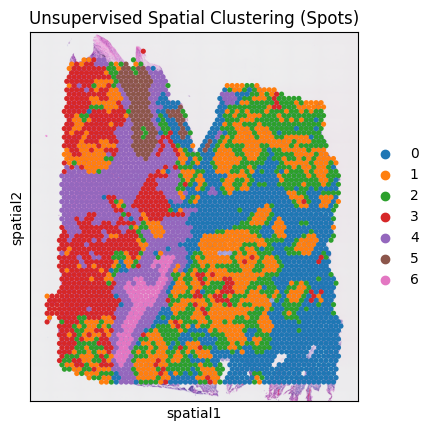

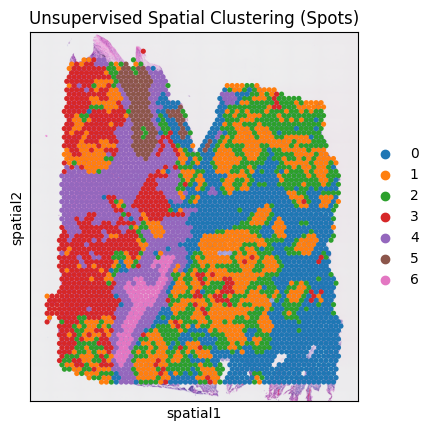

/home/zhangjunyi/anaconda3/envs/NicheCompass/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/zhangjunyi/anaconda3/envs/NicheCompass/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32959 (\N{CJK UNIFIED IDEOGRAPH-80BF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhangjunyi/anaconda3/envs/NicheCompass/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30244 (\N{CJK UNIFIED IDEOGRAPH-7624}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhangjunyi/anaconda3/envs/NicheCompass/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhangjunyi/anaconda3/envs/NicheCompass/lib/python3.9/site-packa

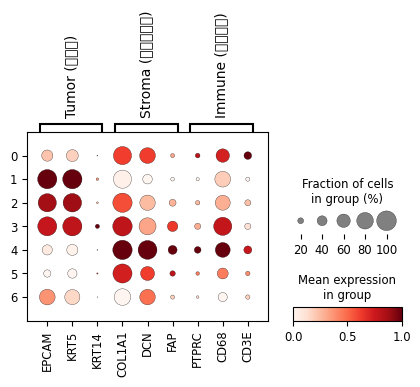

In [13]:
import numpy as np

# 修复步骤：将 spatial 坐标转换为 numpy array
# 注意：我们要确保它是 float 类型以便进行数学运算
adata_vis.obsm['spatial'] = np.array(adata_vis.obsm['spatial']).astype(float)

# 如果你的原始 adata 也有这个问题，建议也修一下（可选）
adata.obsm['spatial'] = np.array(adata.obsm['spatial']).astype(float)

# --- 也就是在这一步之前插入上面的修复代码 ---
# 5. 画出空间聚类图
sc.pl.spatial(adata_vis, color="clusters", title="Unsupervised Spatial Clustering (Spots)", size=1.5)
import scanpy as sc
import matplotlib.pyplot as plt

# 1. 复制一个对象专门用于画图和聚类（不影响 adata 里的原始 counts）
adata_vis = adata.copy()

# 2. 标准化、对数化、寻找高变基因
sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)
sc.pp.highly_variable_genes(adata_vis, n_top_genes=2000)

# 3. 降维与聚类 (PCA -> 邻接图 -> UMAP -> Leiden聚类)
sc.pp.pca(adata_vis)
sc.pp.neighbors(adata_vis, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata_vis)
sc.tl.leiden(adata_vis, key_added="clusters", resolution=0.4) # 分辨率0.4通常能分出5-8个大群

# 4. 把聚类结果同步回我们用来训练的主对象 adata
adata.obs['clusters'] = adata_vis.obs['clusters']

# 5. 画出空间聚类图
sc.pl.spatial(adata_vis, color="clusters", title="Unsupervised Spatial Clustering (Spots)", size=1.5)

# 6. 验证各个群的生物学属性 (肿瘤 vs 正常基质 vs 免疫)
marker_genes = {
    'Tumor (肿瘤区)':['EPCAM', 'KRT5', 'KRT14'],
    'Stroma (基质成纤维)': ['COL1A1', 'DCN', 'FAP'],
    'Immune (免疫浸润)':['PTPRC', 'CD68', 'CD3E']
}
sc.pl.dotplot(adata_vis, marker_genes, groupby='clusters', cmap='Reds', standard_scale='var')

重命名 Cluster 并修正绘图

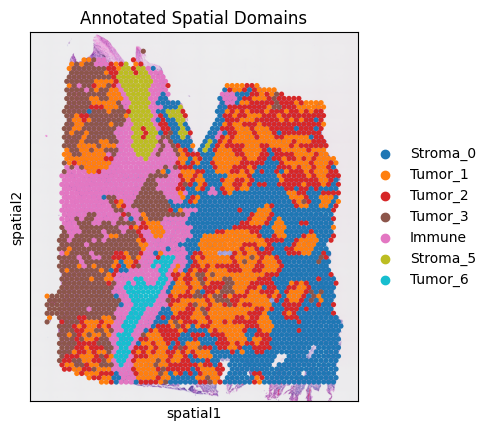

/home/zhangjunyi/anaconda3/envs/NicheCompass/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


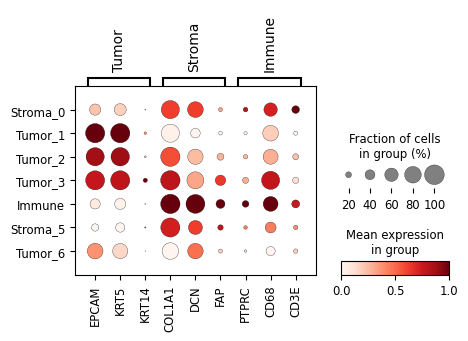

In [14]:
# 1. 定义注释映射字典 (根据上面的读图结果)
# 建议将 0,5 合并为 Stroma，1,2,3,6 合并为 Tumor，或者保留亚群区分
# 这里我们先保留亚群编号，但在大类上命名，避免混淆

rename_dict = {
    '0': 'Stroma_0',
    '1': 'Tumor_1',
    '2': 'Tumor_2',
    '3': 'Tumor_3',
    '4': 'Immune',
    '5': 'Stroma_5',
    '6': 'Tumor_6'
}

# 2. 将注释应用到 adata_vis 和 adata 中
# 注意：我们要把这个分类存为一个新的列，比如 'cell_type'
adata_vis.obs['cell_type'] = adata_vis.obs['clusters'].map(rename_dict)
adata.obs['cell_type'] = adata_vis.obs['cell_type'] # 同步回主数据

# 3. 再次画图验证 (使用英文标签，避免字体报错)
# 空间分布图
sc.pl.spatial(
    adata_vis, 
    color="cell_type", 
    title="Annotated Spatial Domains", 
    size=1.5,
    palette="tab10" # 使用鲜明的配色
)

# 气泡图验证 (Marker key 改成英文)
marker_genes_en = {
    'Tumor': ['EPCAM', 'KRT5', 'KRT14'],
    'Stroma': ['COL1A1', 'DCN', 'FAP'],
    'Immune': ['PTPRC', 'CD68', 'CD3E']
}
sc.pl.dotplot(
    adata_vis, 
    marker_genes_en, 
    groupby='cell_type', 
    cmap='Reds', 
    standard_scale='var'
)

保存结果

In [15]:
# 保存结果到 h5ad 文件
adata.write("my_spatial_data_annotated.h5ad")

print("数据已保存，注释列为 'cell_type'")

数据已保存，注释列为 'cell_type'


In [16]:
import os

# 获取当前工作目录
cwd = os.getcwd()
print(f"当前工作目录是: {cwd}")

# 获取刚才保存文件的完整路径
file_path = os.path.join(cwd, "my_spatial_data_annotated.h5ad")
print(f"文件被保存到了: {file_path}")

当前工作目录是: /home/zhangjunyi/xiangmu/nichecompass-main/temp
文件被保存到了: /home/zhangjunyi/xiangmu/nichecompass-main/temp/my_spatial_data_annotated.h5ad
